# 🧑‍💻 Holistic Data Prepare

##  🎯 Project Objective

- Understand and clean the Customer Credit Risk dataset.
- Handle missing values and outliers.
- Apply encoding and scaling techniques.
- Perform data transformations.
- Create new useful features.
- Prepare a final dataset ready for ML modeling.

### Note : Part A Is a Theoretical part so its was uploded in pdf(doc) form,So you can see it on github

## Part :🅱️ Data Acquisition: CSV Load 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### 2.Load Dataset

##### 2.1 CSV Data load

In [3]:
df=pd.read_csv("customer_credit_risk_dataset.csv")
df.head()

,customer_id,age,gender,region,education_level,employment_type,annual_income,loan_amount,loan_purpose,credit_score,repayment_history,transaction_count,spending_ratio,join_date,default_flag
0,CUST_0001,59.0,Female,West,Graduate,Salaried,1.194882e+06,1.172527e+06,Car,600.610574,3,43,57.209164,2025-06-15,0
1,CUST_0002,49.0,Female,South,Secondary,Self-Employed,9.248440e+05,1.985675e+05,Home,611.120863,0,46,38.323377,2022-12-19,0
2,CUST_0003,35.0,Male,North,Graduate,Salaried,2.110612e+06,7.154323e+04,Home,701.966943,1,41,12.860149,2020-07-21,0
3,CUST_0004,63.0,Female,North,Graduate,Self-Employed,4.301529e+05,3.123945e+05,Business,675.789115,3,47,45.244326,2025-07-25,0
4,CUST_0005,28.0,Other,South,Graduate,Salaried,1.026451e+06,1.001383e+06,Home,320.000000,3,48,68.692816,2019-08-31,0


##### 2.2 Json Data load

In [4]:
json_df = pd.read_json("customer_metadata.json")
json_df.head()

,customer_id,gender,region,education_level,employment_type,join_date
0,CUST_0001,Female,West,Graduate,Salaried,2025-06-15
1,CUST_0002,Female,South,Secondary,Self-Employed,2022-12-19
2,CUST_0003,Male,North,Graduate,Salaried,2020-07-21
3,CUST_0004,Female,North,Graduate,Self-Employed,2025-07-25
4,CUST_0005,Other,South,Graduate,Salaried,2019-08-31


##### 2.3 Sql Data load

In [5]:
import sqlite3

conn = sqlite3.connect("customer_credit_risk.db")

repayment_df = pd.read_sql(
    "SELECT * FROM loan_repayment_history",
    conn
)

repayment_df.head()

,customer_id,missed_payments_last_12_months
0,CUST_0001,3
1,CUST_0002,0
2,CUST_0003,1
3,CUST_0004,3
4,CUST_0005,3


##### 2.4 Dymmmy Api

In [58]:
import requests

# Dummy API URL
url = "http://127.0.0.1:5000/api/economic-indicators"

# Send GET request
response = requests.get(url)

# Check status
print("Status Code:", response.status_code)


# Convert JSON response to Python dictionary
data = response.json()

# Get economic data
economic_data = data["data"]

# Convert to DataFrame
economic_df = pd.DataFrame(economic_data)

# Display data
print("\nEconomic Indicators:")
display(economic_df)

Status Code: 200

Economic Indicators:


,inflation_rate,interest_rate,region,unemployment_rate
0,4.8,6.5,North,5.2
1,4.5,6.5,South,4.7
2,5.1,6.5,East,5.8
3,4.6,6.5,West,4.9


## Part C — Data Understanding & Cleaning

## 4 Explore Data Set using pandas

#### Step 4.1 df.info For Basic Informations Of a data

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        500 non-null    object 
 1   age                475 non-null    float64
 2   gender             475 non-null    object 
 3   region             500 non-null    object 
 4   education_level    500 non-null    object 
 5   employment_type    480 non-null    object 
 6   annual_income      475 non-null    float64
 7   loan_amount        500 non-null    float64
 8   loan_purpose       500 non-null    object 
 9   credit_score       475 non-null    float64
 10  repayment_history  500 non-null    int64  
 11  transaction_count  500 non-null    int64  
 12  spending_ratio     500 non-null    float64
 13  join_date          500 non-null    object 
 14  default_flag       500 non-null    int64  
dtypes: float64(5), int64(3), object(7)
memory usage: 58.7+ KB


#### Step 4.2 df.describe() For Statisrtical Summary

In [60]:
df.describe()

,age,annual_income,loan_amount,credit_score,repayment_history,transaction_count,spending_ratio,default_flag
count,475.000000,4.750000e+02,5.000000e+02,475.000000,500.00000,500.000000,500.000000,500.00000
mean,43.427368,9.182451e+05,7.335549e+05,676.601436,1.82000,44.842000,45.965271,0.13200
std,12.911762,1.656211e+06,1.436419e+06,81.978207,1.46557,6.654442,21.182635,0.33883
min,21.000000,1.500000e+05,5.910538e+04,305.000000,0.00000,26.000000,5.000000,0.00000
25%,32.000000,4.421452e+05,2.920895e+05,626.475752,1.00000,40.000000,32.003643,0.00000
50%,44.000000,6.514649e+05,4.549955e+05,682.022087,2.00000,45.000000,44.634791,0.00000
75%,54.000000,9.518151e+05,7.697824e+05,729.104163,3.00000,49.000000,57.734494,0.00000
max,65.000000,2.200000e+07,2.000000e+07,850.000000,8.00000,66.000000,150.000000,1.00000


#### Step 4.3 — Categorical data description

In [61]:
df.describe(include="object")

,customer_id,gender,region,education_level,employment_type,loan_purpose,join_date
count,500,475,500,500,480,500,500
unique,500,3,4,4,3,5,459
top,CUST_0500,Male,North,Graduate,Salaried,Home,2022-12-16
freq,1,319,133,221,300,164,3


## 5 Pandas Profiling → Data Quality Report

#### 5.1 Import liabries 

In [62]:
from ydata_profiling import ProfileReport

C:\Users\rosha\AppData\Local\Temp\ipykernel_29100\44057814.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


#### Step 5.3 Create Report

In [63]:
profile = ProfileReport(
    df,
    title="Customer Credit Risk - Data Quality Report",
    explorative=True
)
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|█████████████████████████████████████████████████████████████████████████████████| 15/15 [00:00<00:00, 217.49it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

## 6 Missing Data Handling

### raw copy 

In [66]:
df_raw = df.copy()

### Cheack Missing value

In [67]:
df.isnull().sum()

customer_id           0
age                  25
gender               25
region                0
education_level       0
employment_type      20
annual_income        25
loan_amount           0
loan_purpose          0
credit_score         25
repayment_history     0
transaction_count     0
spending_ratio        0
join_date             0
default_flag          0
dtype: int64

#### Only Numerical Data

In [69]:
numeric_null_counts = df.select_dtypes(include=[np.number]).isnull().sum()

numeric_null_counts = numeric_null_counts[numeric_null_counts > 0]

print(numeric_null_counts)

age              25
annual_income    25
credit_score     25
dtype: int64


#### 6.1 Simple Imputer — Numerical

In [70]:
from sklearn.impute import SimpleImputer

numerical_columns = [
    "age",
    "annual_income",
    "loan_amount",
    "credit_score"
]

df_simple_num = df_raw.copy()

imputer_mean = SimpleImputer(strategy="mean")

df_simple_num[numerical_columns] = imputer_mean.fit_transform(
    df_simple_num[numerical_columns]
)

In [71]:
print(df_simple_num[numerical_columns].isnull().sum())

age              0
annual_income    0
loan_amount      0
credit_score     0
dtype: int64


## 6.2 Simple Imputer — Categorical

In [72]:
categorical_null_counts = df.select_dtypes(include=['object', 'category']).isnull().sum()

categorical_null_counts = categorical_null_counts[categorical_null_counts > 0]

print(categorical_null_counts)

gender             25
employment_type    20
dtype: int64


In [73]:
categorical_columns = [
    "gender",
    "employment_type"
]

In [74]:
df_simple_cat = df_raw.copy()

imputer_cat = SimpleImputer(strategy="most_frequent")

df_simple_cat[categorical_columns] = imputer_cat.fit_transform(
    df_simple_cat[categorical_columns]
)

In [75]:
print(df_simple_cat[categorical_columns].isnull().sum())

gender             0
employment_type    0
dtype: int64


### interpretation

For categorical variables, I used the most frequent category to replace missing values.

## 6.3 Most Frequent Category Imputation

In [76]:
df_most_frequent = df_raw.copy()

most_frequent_gender = df_most_frequent["gender"].mode()[0]

df_most_frequent["gender"] = df_most_frequent["gender"].fillna(
    most_frequent_gender
)

In [77]:
print("Most frequent gender:", most_frequent_gender)
print(df_most_frequent["gender"].isnull().sum())

Most frequent gender: Male
0


## 6.4 Missing Indicator + Random Sample Imputation

In [78]:
df_random = df_raw.copy()

df_random["annual_income_missing"] = (
    df_random["annual_income"].isnull().astype(int)
)

In [79]:
missing_count = df_random["annual_income"].isnull().sum()

sample_values = df_random["annual_income"].dropna().sample(
    missing_count,
    random_state=42
).values

df_random.loc[
    df_random["annual_income"].isnull(),
    "annual_income"
] = sample_values

In [80]:
print(df_random["annual_income_missing"].value_counts())
print(df_random["annual_income"].isnull().sum())

annual_income_missing
0    475
1     25
Name: count, dtype: int64
0


## 6.5 KNN Imputer — Multivariate

In [81]:
from sklearn.impute import KNNImputer

df_knn = df_raw.copy()

knn_columns = [
    "annual_income",
    "loan_amount",
    "credit_score"
]

knn_imputer = KNNImputer(n_neighbors=5)

df_knn[knn_columns] = knn_imputer.fit_transform(
    df_knn[knn_columns]
)

In [82]:
print(df_knn[knn_columns].isnull().sum())

annual_income    0
loan_amount      0
credit_score     0
dtype: int64


### interpretation
KNN Imputer uses values from similar observations, or nearest neighbors, to estimate missing values.

## 6.6 MICE Algorithm

#### Import liabaries

In [83]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

In [84]:
df_mice = df_raw.copy()

mice_columns = [
    "annual_income",
    "loan_amount",
    "credit_score"
]

mice_imputer = IterativeImputer(
    random_state=42
)

df_mice[mice_columns] = mice_imputer.fit_transform(
    df_mice[mice_columns]
)

In [85]:
print(df_mice[mice_columns].isnull().sum())

annual_income    0
loan_amount      0
credit_score     0
dtype: int64


### interpretation
MICE stands for Multiple Imputation by Chained Equations. It estimates missing values iteratively using relationships between variables.

## 6.7 Complete Case Analysis

#### Rows

In [86]:
df_complete_rows = df_raw.dropna()

print("Original rows:", len(df_raw))
print("Rows after Complete Case Analysis:", len(df_complete_rows))

Original rows: 500
Rows after Complete Case Analysis: 388


#### Columns

In [87]:
df_complete_columns = df_raw.dropna(axis=1)

print("Original columns:", df_raw.shape[1])
print("Columns after dropping columns with missing values:",
      df_complete_columns.shape[1])

Original columns: 15
Columns after dropping columns with missing values: 10


## PART D — OUTLIER HANDLING

#### Step 7.0 —  prepare Raw dataset

In [88]:
df = pd.read_csv("customer_credit_risk_dataset.csv")

df_outlier = df.copy() # Raw dataset copy

print("Dataset shape:", df_outlier.shape)

Dataset shape: (500, 15)


In [89]:
numeric_columns = [
    "age",
    "annual_income",
    "loan_amount",
    "credit_score",
    "repayment_history",
    "transaction_count",
    "spending_ratio"
]

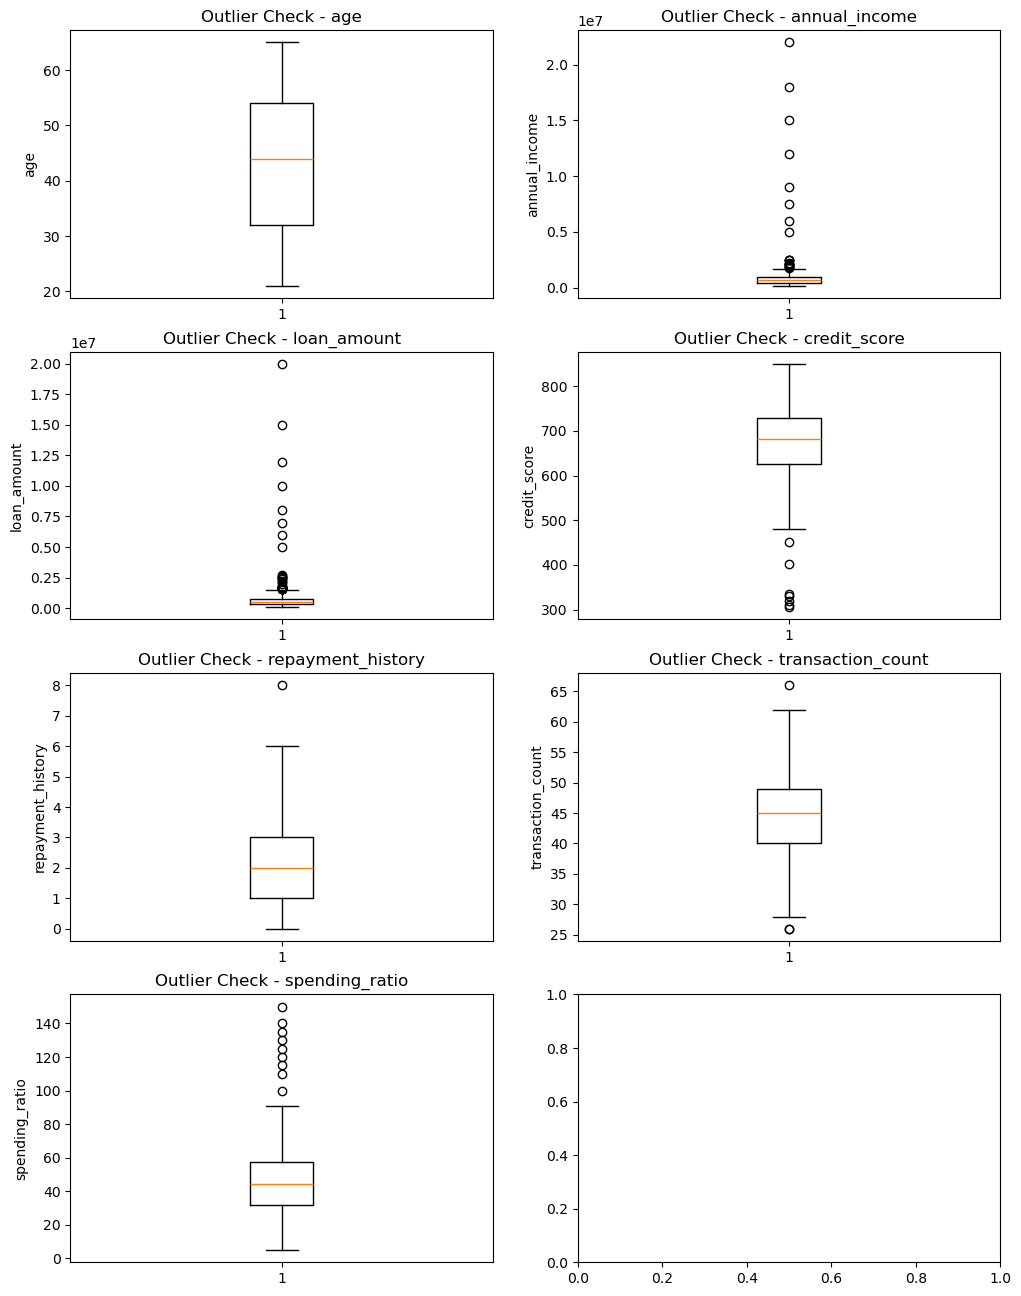

In [90]:
fig, axes = plt.subplots(
    4, 2,
    figsize=(12, 16)
)

axes = axes.flatten()

for i, column in enumerate(numeric_columns):

    axes[i].boxplot(
        df[column].dropna()
    )

    axes[i].set_title(
        "Outlier Check - " + column
    )

    axes[i].set_ylabel(column)

plt.show()

#### Step 7.1 Z-score Method
Z-score method was used to detect outliers in the credit_score variable. Observations having an absolute Z-score greater than 3 were considered outliers. These extreme observations were removed to reduce the effect of unusual values on the dataset. The before-and-after boxplots show the change in the distribution after outlier treatment.

In [91]:
df_zscore = df.copy()

In [92]:
from scipy.stats import zscore

In [112]:
df_zscore["credit_score_zscore"] = zscore(
    df_zscore["credit_score"],
    nan_policy="omit"
)

####  Identify outliers

In [113]:
outliers_zscore = df_zscore[
    df_zscore["credit_score_zscore"].abs() > 3
]

print("Number of Z-score outliers:",
      len(outliers_zscore))

# Display outliers
display(
    outliers_zscore[
        ["customer_id", "credit_score", "credit_score_zscore"]
    ]
)

Number of Z-score outliers: 6


,customer_id,credit_score,credit_score_zscore
4,CUST_0005,320.000000,-4.354540
17,CUST_0018,335.000000,-4.171372
96,CUST_0097,330.000000,-4.232428
218,CUST_0219,401.840254,-3.355171
259,CUST_0260,305.000000,-4.537709
305,CUST_0306,310.000000,-4.476652


####  Remove outliers

In [114]:
df_zscore_clean = df_zscore[
    df_zscore["credit_score_zscore"].abs() <= 3
].copy()

# Remove helper column
df_zscore_clean.drop(
    columns=["credit_score_zscore"],
    inplace=True
)

In [115]:
# Before and after
print("\nOriginal rows:", len(df_zscore))
print("Rows after treatment:", len(df_zscore_clean))
print("Rows removed:",
      len(df_zscore) - len(df_zscore_clean))


Original rows: 500
Rows after treatment: 469
Rows removed: 31


#### Before and After Graph

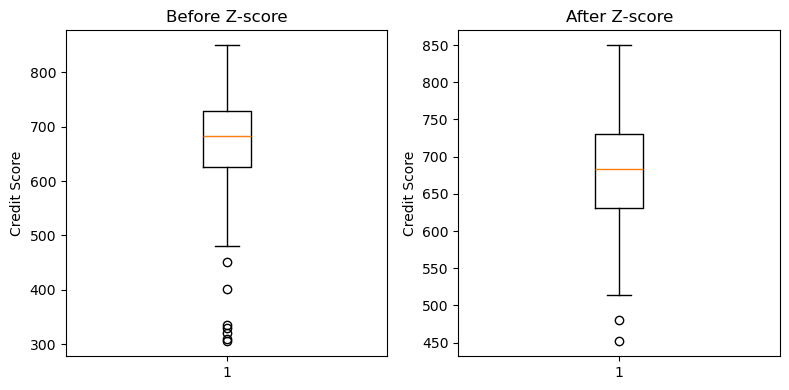

In [116]:
plt.figure(figsize=(8, 4))

# Before
plt.subplot(1, 2, 1)
plt.boxplot(df_zscore["credit_score"].dropna())
plt.title("Before Z-score")
plt.ylabel("Credit Score")

# After
plt.subplot(1, 2, 2)
plt.boxplot(df_zscore_clean["credit_score"].dropna())
plt.title("After Z-score")
plt.ylabel("Credit Score")

plt.tight_layout()
plt.show()

### Interpretation  
Z-score method was used to detect outliers in the credit_score variable. Observations with an absolute Z-score greater than 3 were considered outliers and removed. The before-and-after boxplots show that extreme observations were reduced after treatment.

## Step 7.2 IQR Method

In [117]:
df_iqr = pd.read_csv("customer_credit_risk_dataset.csv")

# Q1 and Q3
Q1 = df_iqr["annual_income"].quantile(0.25)
Q3 = df_iqr["annual_income"].quantile(0.75)

# IQR
IQR = Q3 - Q1

# Lower and Upper limits
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

Q1: 442145.2372724111
Q3: 951815.0508337596
IQR: 509669.8135613485
Lower Limit: -322359.4830696116
Upper Limit: 1716319.7711757822


#### Identify Outlier

In [118]:
outliers_iqr = df_iqr[
    (df_iqr["annual_income"] < lower_limit) |
    (df_iqr["annual_income"] > upper_limit)
]

print("Number of outliers:", len(outliers_iqr))

Number of outliers: 20


#### Remove  Outlier

In [119]:
df_iqr_clean = df_iqr[
    (df_iqr["annual_income"] >= lower_limit) &
    (df_iqr["annual_income"] <= upper_limit)
].copy()

print("Original rows:", len(df_iqr))
print("After IQR treatment:", len(df_iqr_clean))
print("Rows removed:", len(df_iqr) - len(df_iqr_clean))

Original rows: 500
After IQR treatment: 455
Rows removed: 45


#### Before & After Graph

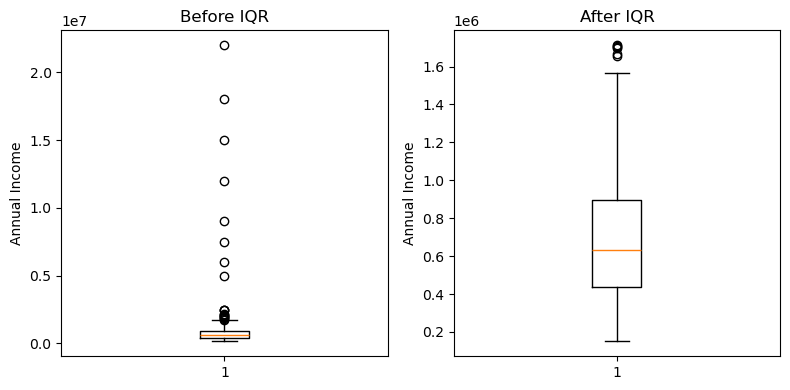

In [120]:
plt.figure(figsize=(8, 4))

# Before
plt.subplot(1, 2, 1)
plt.boxplot(df_iqr["annual_income"].dropna())
plt.title("Before IQR")
plt.ylabel("Annual Income")

# After
plt.subplot(1, 2, 2)
plt.boxplot(df_iqr_clean["annual_income"].dropna())
plt.title("After IQR")
plt.ylabel("Annual Income")

plt.tight_layout()
plt.show()

#### Interpretation:

IQR method was used to detect outliers in the annual_income variable. The lower and upper boundaries were calculated using Q1 − 1.5×IQR and Q3 + 1.5×IQR. Values outside these limits were considered outliers and removed. The boxplots show that extreme income values were reduced after treatment.

## Step 7.3: Percentile Method
The percentile method was used to detect extreme values in annual_income. Values below the 1st percentile and above the 99th percentile were considered outliers and removed. The before-and-after boxplots show that the extreme income values were reduced after treatment.

In [121]:
df_percentile = pd.read_csv("customer_credit_risk_dataset.csv")

## 1st aur 99th percentile calculate

In [122]:
lower_limit = df_percentile["annual_income"].quantile(0.01)
upper_limit = df_percentile["annual_income"].quantile(0.99)

print("1st Percentile:", lower_limit)
print("99th Percentile:", upper_limit)

1st Percentile: 200172.19327259646
99th Percentile: 7889999.999999986


#### Identify Outlier

In [123]:
outliers_percentile = df_percentile[
    (df_percentile["annual_income"] < lower_limit) |
    (df_percentile["annual_income"] > upper_limit)
]

print("Number of outliers:", len(outliers_percentile))

Number of outliers: 10


#### Remove Outliers

In [124]:
df_percentile_clean = df_percentile[
    (df_percentile["annual_income"] >= lower_limit) &
    (df_percentile["annual_income"] <= upper_limit)
].copy()

print("Original rows:", len(df_percentile))
print("After treatment:", len(df_percentile_clean))
print("Rows removed:", len(df_percentile) - len(df_percentile_clean))

Original rows: 500
After treatment: 465
Rows removed: 35


#### Before And After Graph

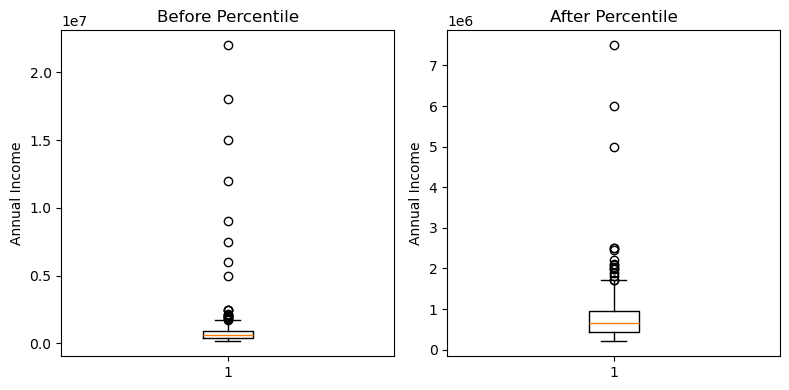

In [125]:
plt.figure(figsize=(8, 4))

# Before
plt.subplot(1, 2, 1)
plt.boxplot(df_percentile["annual_income"].dropna())
plt.title("Before Percentile")
plt.ylabel("Annual Income")

# After
plt.subplot(1, 2, 2)
plt.boxplot(df_percentile_clean["annual_income"].dropna())
plt.title("After Percentile")
plt.ylabel("Annual Income")

plt.tight_layout()
plt.show()

#### Interpretation
The percentile method was applied to annual_income using the 1st and 99th percentiles as boundaries. Values below the 1st percentile and above the 99th percentile were considered extreme values and removed. The before-and-after boxplots show the reduction of extreme values.

## Step 7.4: Winsorization Technique

In [126]:
original_df = pd.read_csv("customer_credit_risk_dataset.csv")

In [127]:
# Numerical columns
numeric_columns = [
    "age",
    "annual_income",
    "loan_amount",
    "credit_score",
    "repayment_history",
    "transaction_count",
    "spending_ratio"
]

#### Winsorizatation Copy

In [128]:
winsor_df = original_df.copy()

#### Apply Winsorizationn

In [129]:
for column in numeric_columns:
    
    lower_limit = winsor_df[column].quantile(0.01)
    upper_limit = winsor_df[column].quantile(0.99)
    
    winsor_df[column] = winsor_df[column].clip(
        lower=lower_limit,
        upper=upper_limit
    )


In [131]:
print("Original rows: 500")
print("Rows after Winsorization:", len(winsor_df))

Original rows: 500
Rows after Winsorization: 500


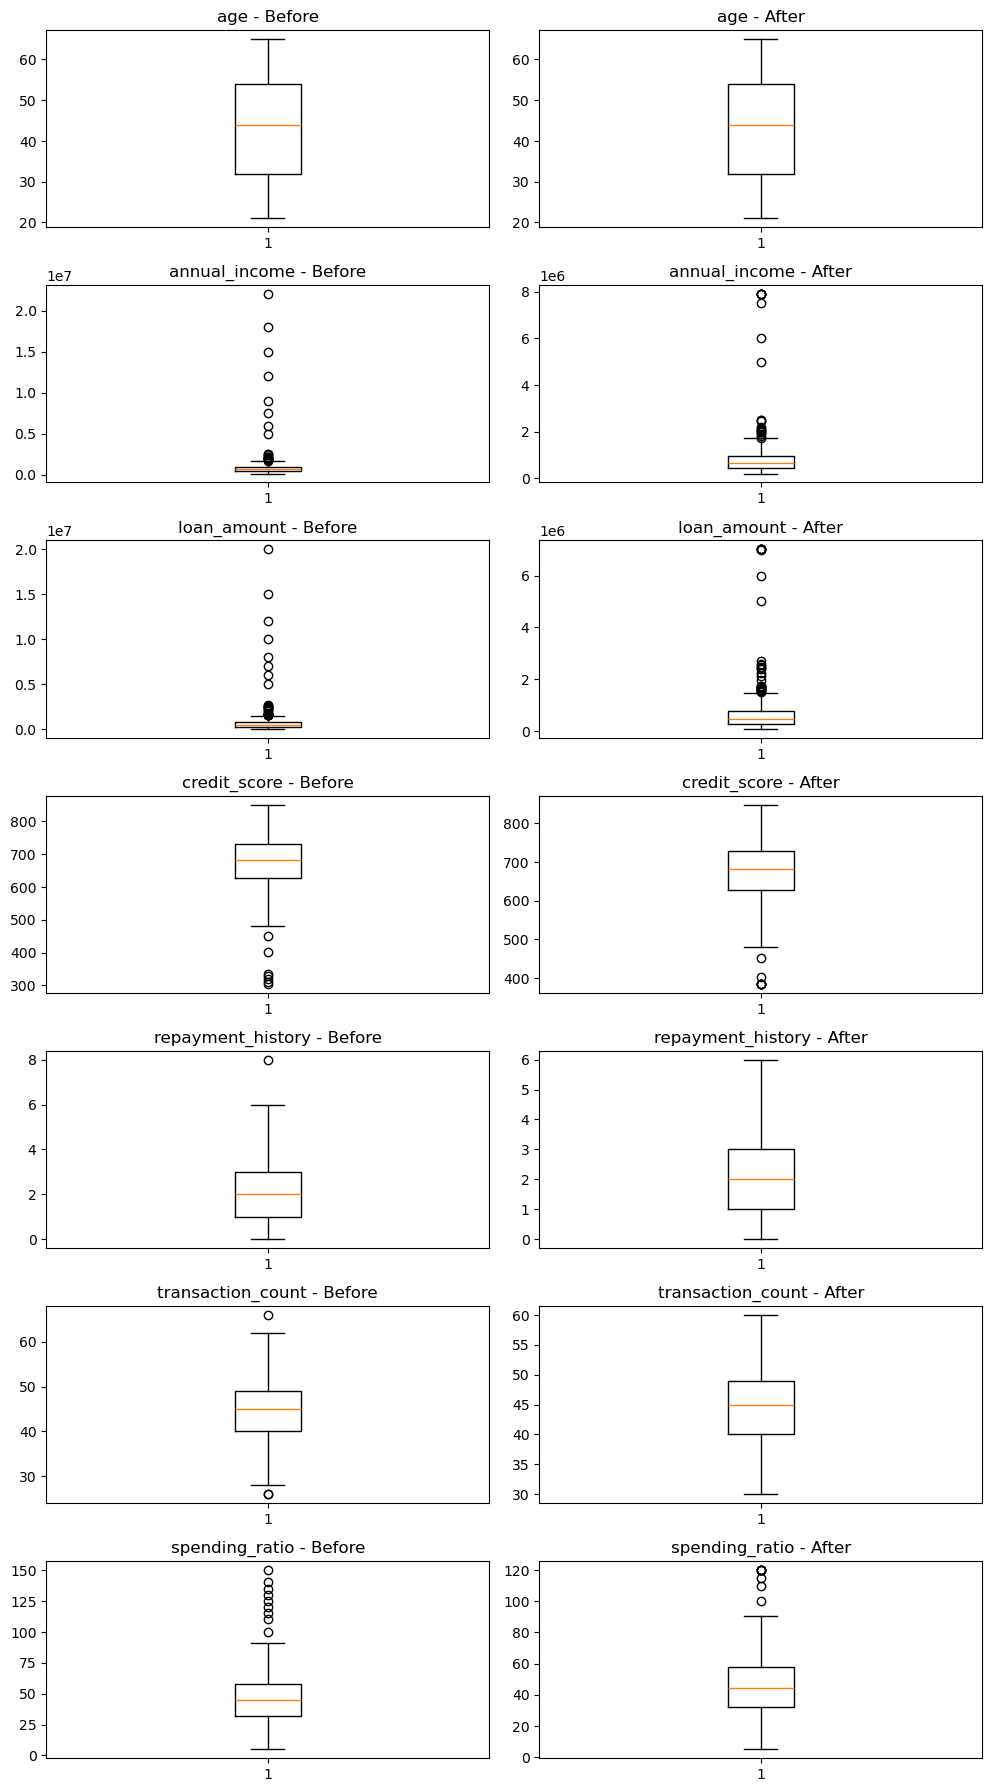

In [132]:
fig, axes = plt.subplots(
    7, 2,
    figsize=(10, 18)
)

for i, column in enumerate(numeric_columns):

    # Before
    axes[i, 0].boxplot(original_df[column].dropna())
    axes[i, 0].set_title(column + " - Before")

    # After
    axes[i, 1].boxplot(winsor_df[column].dropna())
    axes[i, 1].set_title(column + " - After")

plt.tight_layout(pad=1)
plt.show()

#### Interpretation

Winsorization was applied to all selected numerical features using the 1st and 99th percentile limits. Extreme values were capped at these limits instead of being removed. Therefore, the number of observations remained unchanged while the influence of extreme values was reduced.

# PART E — FEATURE ENGINEERING

## Step 8 Handle variable Types

#### Step 8.1 — Mixed Variables

In [133]:
df = pd.read_csv("customer_credit_risk_dataset.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


#### Numerical variables

In [134]:
numeric_columns = [
    "age",
    "annual_income",
    "loan_amount",
    "credit_score",
    "repayment_history",
    "transaction_count",
    "spending_ratio"
]

print("Numerical Columns:")
print(numeric_columns)

Numerical Columns:
['age', 'annual_income', 'loan_amount', 'credit_score', 'repayment_history', 'transaction_count', 'spending_ratio']


In [135]:
print(df[numeric_columns].dtypes)

print("\nCategorical Data Types:")
print(df[categorical_columns].dtypes)

age                  float64
annual_income        float64
loan_amount          float64
credit_score         float64
repayment_history      int64
transaction_count      int64
spending_ratio       float64
dtype: object

Categorical Data Types:
gender             object
employment_type    object
dtype: object


#### Interpretation
so A Mix Varibale Means A dataset containing both numerical and categorical variables is called a mixed-variable dataset

## Step 8.2 — Date & Time Variables

#### Check join_date dtype (Original(Before))

In [147]:
print(df['join_date'].dtype)

object


#### Convert Date To Date time

In [149]:
df["join_date"] = pd.to_datetime(df["join_date"])

In [150]:
print(df['join_date'].dtype) # After Convert to date and time

datetime64[ns]


#### Extract Year

In [158]:
df["join_year"] = df["join_date"].dt.year

#### Excract Month

In [159]:
df["join_month"] = df["join_date"].dt.month

#### Extract Day

In [160]:
df["join_day"] = df["join_date"].dt.day

#### Extract Weekend

In [161]:
df["join_weekday"] = df["join_date"].dt.day_name()

### Check Result 

In [163]:
df[["join_date","join_year","join_month","join_day","join_weekday"]].head()


,join_date,join_year,join_month,join_day,join_weekday
0,2025-06-15,2025,6,15,Sunday
1,2022-12-19,2022,12,19,Monday
2,2020-07-21,2020,7,21,Tuesday
3,2025-07-25,2025,7,25,Friday
4,2019-08-31,2019,8,31,Saturday


## Step 9.1: Ordinal Encoding

In [165]:
from sklearn.preprocessing import OrdinalEncoder

#### Check A Categories

In [164]:
df["education_level"].unique()

array(['Graduate', 'Secondary', 'Primary', 'Post-Graduate'], dtype=object)

### Apply Encoding 

In [166]:
education_order = [
    ["Primary", "Secondary", "Graduate", "Post-Graduate"]
]

ordinal_encoder = OrdinalEncoder(
    categories=education_order
)

df["education_level_encoded"] = ordinal_encoder.fit_transform(
    df[["education_level"]]
)

#### Before and After

In [167]:
df[
    ["education_level", "education_level_encoded"]
].head(10)

,education_level,education_level_encoded
0,Graduate,2.0
1,Secondary,1.0
2,Graduate,2.0
3,Graduate,2.0
4,Graduate,2.0
5,Primary,0.0
6,Graduate,2.0
7,Secondary,1.0
8,Graduate,2.0
9,Post-Graduate,3.0


#### Interpretation
Ordinal Encoding converts categorical values into numerical values while preserving their natural order.

### Step 9.2: Label Encoding

In [168]:
from sklearn.preprocessing import LabelEncoder

#### Create encoder

In [170]:
label_encoder = LabelEncoder()

#### Apply Label Encoder

In [171]:
df["default_flag_encoded"] = label_encoder.fit_transform(
    df["default_flag"]
)

In [172]:
df[
    ["default_flag", "default_flag_encoded"]
].head(10)

,default_flag,default_flag_encoded
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,0,0
8,1,1
9,0,0


#### NOTE 
##### 0 = No Default
##### 1= Default

#### Interpretaton
Label Encoding converts categorical classes into numerical labels.

##### And why after the label encoding value is still same ?
so beause the original feature was already represented as binary numerical values, so Label Encoding does not change the representation

### Step 9.3: One-Hot 
a method that converts text or category names into numbers (0s and 1s) so machine learning models can process them

In [176]:
from sklearn.preprocessing import OneHotEncoder

#### Crete Encoder

In [177]:
onehot_encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore"
)

#### Encode Both Columns

In [178]:
encoded_data = onehot_encoder.fit_transform(
    df[["region", "loan_purpose"]]
)

#### Crete A Encoded Column NAme

In [179]:
encoded_columns = onehot_encoder.get_feature_names_out(
    ["region", "loan_purpose"]
)

print(encoded_columns)

['region_East' 'region_North' 'region_South' 'region_West'
 'loan_purpose_Business' 'loan_purpose_Car' 'loan_purpose_Education'
 'loan_purpose_Home' 'loan_purpose_Other']


#### Now Convert to Data Frame

In [180]:
encoded_df = pd.DataFrame(
    encoded_data,
    columns=encoded_columns,
    index=df.index
)

#### Before and after

In [181]:
print("Before Encoding:")
display(df[["region", "loan_purpose"]].head())

print("After One-Hot Encoding:")
display(encoded_df.head())

Before Encoding:


,region,loan_purpose
0,West,Car
1,South,Home
2,North,Home
3,North,Business
4,South,Home


After One-Hot Encoding:


,region_East,region_North,region_South,region_West,loan_purpose_Business,loan_purpose_Car,loan_purpose_Education,loan_purpose_Home,loan_purpose_Other
0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


#### Interpretation


## Step 10.1: Binning
Binning means the process of converting continuous numerical values into discrete groups or intervals.

In [182]:
df = pd.read_csv("customer_credit_risk_dataset.csv")

#### Create a Incoem Group

In [183]:
income_bins = [0, 300000, 600000, 1000000, float("inf")]

income_labels = [
    "Low",
    "Medium",
    "High",
    "Very High"
]

df["income_group"] = pd.cut(
    df["annual_income"],
    bins=income_bins,
    labels=income_labels
)

#### Before And After

In [184]:
display(
    df[
        ["annual_income", "income_group"]
    ].head(10)
)

,annual_income,income_group
0,1.194882e+06,Very High
1,9.248440e+05,High
2,2.110612e+06,Very High
3,4.301529e+05,Medium
4,1.026451e+06,Very High
5,3.714611e+05,Medium
6,2.673399e+05,Low
7,2.121790e+05,Low
8,8.739740e+05,High
9,7.193217e+05,High


In [185]:
print(df["income_group"].value_counts())

income_group
Medium       178
High         155
Very High    105
Low           37
Name: count, dtype: int64


#### Interpretation


## Step 10.2: Binarization
Binarization converts numerical values into two binary categories, usually 0 and 1, based on a threshold

#### Apply Binarizatio

In [187]:
df["high_credit_score"] = (
    df["credit_score"] > 700
).astype(int)

#### Before and after

In [188]:
display(
    df[
        ["credit_score", "high_credit_score"]
    ].head(10)
)

,credit_score,high_credit_score
0,600.610574,0
1,611.120863,0
2,701.966943,1
3,675.789115,0
4,320.000000,0
5,739.315258,1
6,739.158874,1
7,699.731060,0
8,607.835079,0
9,704.400447,1


In [190]:
print(
    df["high_credit_score"].value_counts()
)

high_credit_score
0    312
1    188
Name: count, dtype: int64


#### Interpretation 
Binarization was applied to the credit score using 700 as the threshold. Customers with a credit score greater than 700 were assigned 1, while the remaining customers were assigned 0. This converts the continuous credit score into a binary feature

## Step 10.3: Quantile Binning
Quantile Binning divides the data into groups containing approximately equal numbers of observations

Quantile Binning

In [192]:
df["income_quantile"] = pd.qcut(
    df["annual_income"],
    q=4,
    labels=[
        "Low",
        "Medium-Low",
        "Medium-High",
        "High"
    ]
)

#### Result

In [193]:
display(
    df[
        ["annual_income", "income_quantile"]
    ].head(10)
)

,annual_income,income_quantile
0,1.194882e+06,High
1,9.248440e+05,Medium-High
2,2.110612e+06,High
3,4.301529e+05,Low
4,1.026451e+06,High
5,3.714611e+05,Low
6,2.673399e+05,Low
7,2.121790e+05,Low
8,8.739740e+05,Medium-High
9,7.193217e+05,Medium-High


In [194]:
print(
    df["income_quantile"].value_counts()
)

income_quantile
Low            119
Medium-Low     119
High           119
Medium-High    118
Name: count, dtype: int64


##### Interpretation

Quantile binning was applied to annual income using four quantile groups. The continuous income values were converted into four categories containing approximately equal numbers of observations.

## Step 10.4: K-Means Binning
K-Means Binning uses the K-Means clustering algorithm to divide continuous numerical values into groups based on similarity

In [195]:
from sklearn.cluster import KMeans

In [197]:
income_data = df[["annual_income"]].dropna() # Temporly Remove Missing value Beacuse k mene not working firectly to missing values

#### Apply k Means

In [209]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

income_data["income_cluster"] = kmeans.fit_predict(
    income_data[["annual_income"]]
)

C:\Users\rosha\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [210]:
print("Income Group Centers:")

print(
    kmeans.cluster_centers_
)

Income Group Centers:
[[  538691.15608981]
 [18333333.33333333]
 [ 7900000.        ]
 [ 1265284.99506968]]


#### Add Result In orginal Df

In [207]:
df.loc[
    income_data.index,
    "income_kmeans_group"
] = income_data["income_cluster"]

#### Check

In [211]:
display(
    df[
        ["annual_income", "income_kmeans_group"]
    ].head(10)
)

,annual_income,income_kmeans_group
0,1.194882e+06,3.0
1,9.248440e+05,3.0
2,2.110612e+06,3.0
3,4.301529e+05,0.0
4,1.026451e+06,3.0
5,3.714611e+05,0.0
6,2.673399e+05,0.0
7,2.121790e+05,0.0
8,8.739740e+05,0.0
9,7.193217e+05,0.0


In [212]:
print(
    df["income_kmeans_group"].value_counts()
)

income_kmeans_group
0.0    342
3.0    125
2.0      5
1.0      3
Name: count, dtype: int64


#### Interpretation

K-Means Binning was applied to annual income by creating four clusters. The algorithm grouped customers according to the similarity of their income values. The resulting cluster labels represent different income groups.

# Part F — Feature Scalling

## Step 11.1: Standardization (Z-score Scaling)
Standardization transforms numerical data so that it has approximately mean 0 and standard deviation 1.

In [214]:
df = pd.read_csv("customer_credit_risk_dataset.csv")

In [216]:
from sklearn.preprocessing import StandardScaler

#### Numerical Column

In [215]:
numeric_columns = [
    "age",
    "annual_income",
    "loan_amount",
    "credit_score",
    "repayment_history",
    "transaction_count",
    "spending_ratio"
]

#### Apply Sandarization

In [217]:
scaler = StandardScaler()

df_standardized = df.copy()

df_standardized[numeric_columns] = scaler.fit_transform(
    df_standardized[numeric_columns]
)

#### Before and After

In [218]:
print("Before Standardization:")
display(df[numeric_columns].head())

print("\nAfter Standardization:")
display(df_standardized[numeric_columns].head())

Before Standardization:


,age,annual_income,loan_amount,credit_score,repayment_history,transaction_count,spending_ratio
0,59.0,1.194882e+06,1.172527e+06,600.610574,3,43,57.209164
1,49.0,9.248440e+05,1.985675e+05,611.120863,0,46,38.323377
2,35.0,2.110612e+06,7.154323e+04,701.966943,1,41,12.860149
3,63.0,4.301529e+05,3.123945e+05,675.789115,3,47,45.244326
4,28.0,1.026451e+06,1.001383e+06,320.000000,3,48,68.692816



After Standardization:


,age,annual_income,loan_amount,credit_score,repayment_history,transaction_count,spending_ratio
0,1.207353,0.167206,0.305908,-0.927941,0.805954,-0.277085,0.531339
1,0.432048,0.003989,-0.372818,-0.799598,-1.243081,0.174193,-0.361124
2,-0.653377,0.720696,-0.461338,0.309744,-0.560070,-0.577937,-1.564408
3,1.517474,-0.295015,-0.293495,-0.009919,0.805954,0.324619,-0.034069
4,-1.196090,0.065402,0.186642,-4.354540,0.805954,0.475045,1.074007


#### Before vs After Graph

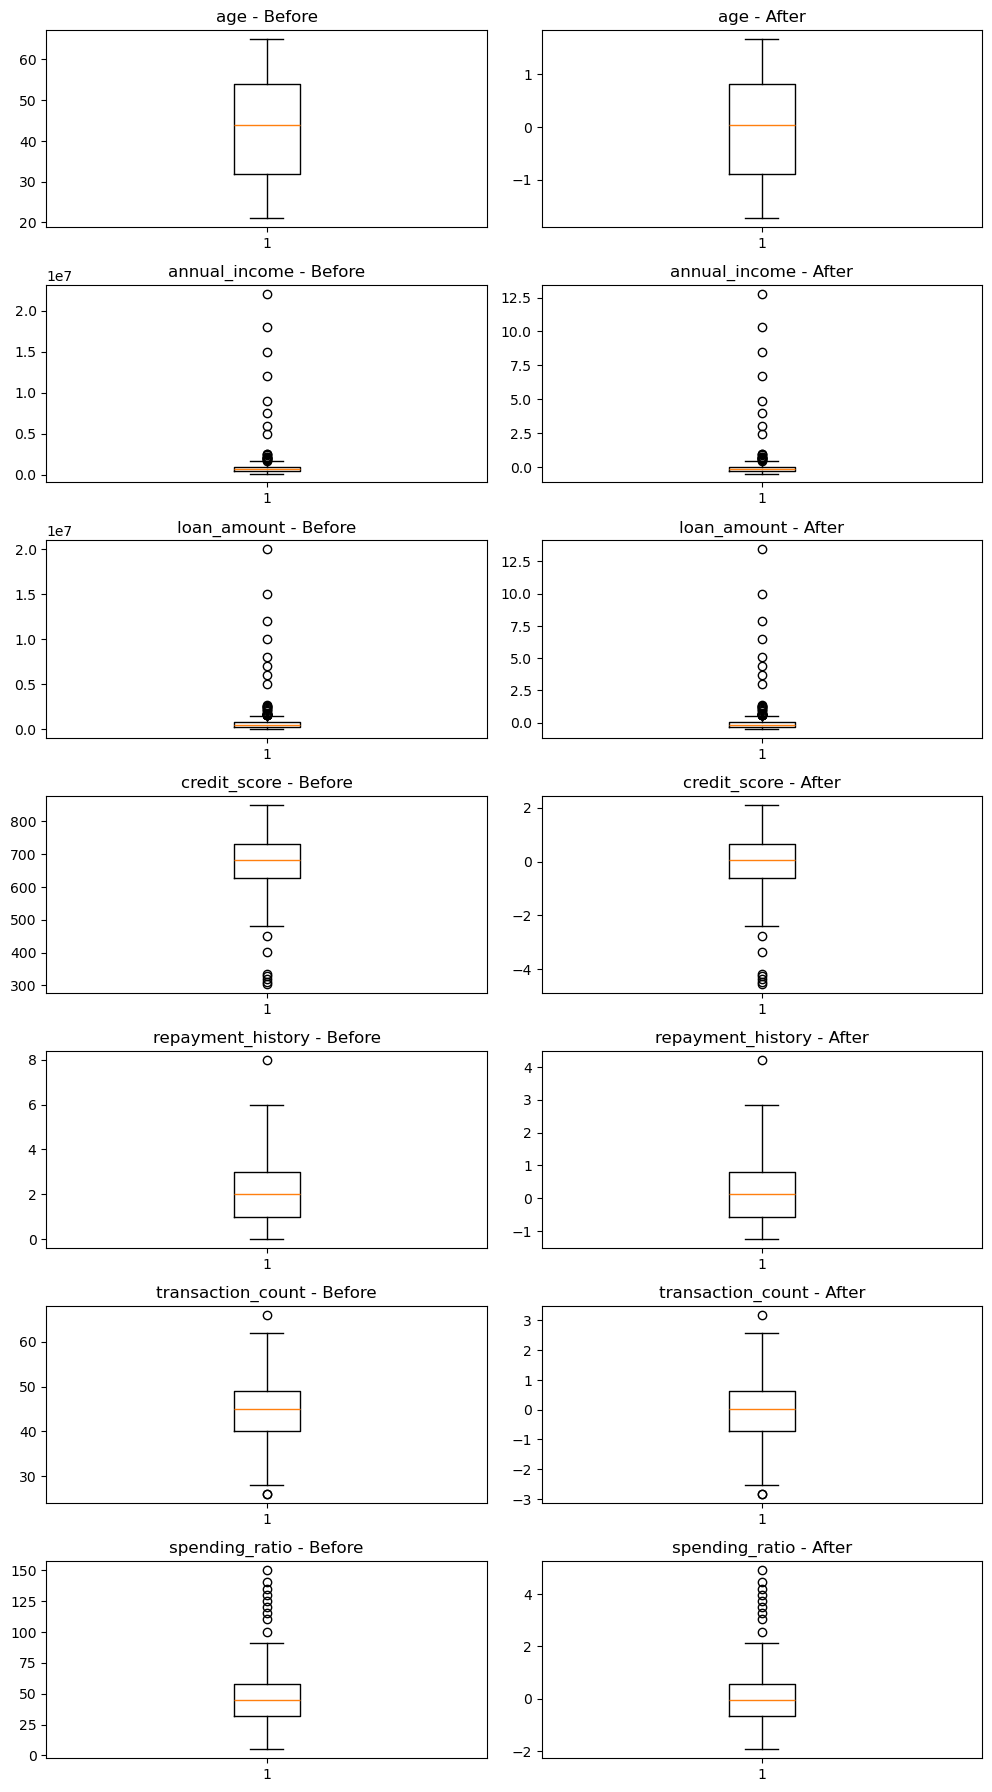

In [219]:


fig, axes = plt.subplots(
    7, 2,
    figsize=(10, 18)
)

for i, column in enumerate(numeric_columns):

    # Before
    axes[i, 0].boxplot(
        df[column].dropna()
    )
    axes[i, 0].set_title(column + " - Before")

    # After
    axes[i, 1].boxplot(
        df_standardized[column].dropna()
    )
    axes[i, 1].set_title(column + " - After")

plt.tight_layout(pad=1)
plt.show()

## Graph mein outliers after scaling bhi dikh rahe hain.

Beause Scaling ka purpose hai different numerical features ko comparable scale par lana, not outlier removal

#### Check MEand And Standar deviation

In [220]:
print("Means after standardization:")
print(df_standardized[numeric_columns].mean())

print("\nStandard deviations after standardization:")
print(df_standardized[numeric_columns].std())

Means after standardization:
age                 -1.869849e-16
annual_income        7.479397e-18
loan_amount          3.552714e-17
credit_score        -8.676101e-16
repayment_history   -4.973799e-17
transaction_count    1.918465e-16
spending_ratio       2.220446e-16
dtype: float64

Standard deviations after standardization:
age                  1.001054
annual_income        1.001054
loan_amount          1.001002
credit_score         1.001054
repayment_history    1.001002
transaction_count    1.001002
spending_ratio       1.001002
dtype: float64


#### Interpretation
Standardization was applied to the numerical features using Z-score scaling. The features were transformed to have approximately a mean of 0 and a standard deviation of 1. This puts numerical variables on a comparable scale without removing observations.

## Step 11.2: Normalization
Normalization scales the values to a common magnitude, usually on a row-wise basis

In [222]:
from sklearn.preprocessing import Normalizer

#### Numerical Column

In [223]:
numeric_columns = [
    "age",
    "annual_income",
    "loan_amount",
    "credit_score",
    "repayment_history",
    "transaction_count",
    "spending_ratio"
]

In [227]:
df_normalized = df.copy()

df_normalized[numeric_columns] = df_normalized[numeric_columns].fillna(
    df_normalized[numeric_columns].median()
)

#### Apply normalization

In [228]:
normalizer = Normalizer()

df_normalized[numeric_columns] = normalizer.fit_transform(
    df_normalized[numeric_columns]
)

In [229]:
print("Before Normalization:")
display(df[numeric_columns].head())

print("\nAfter Normalization:")
display(df_normalized[numeric_columns].head())

Before Normalization:


,age,annual_income,loan_amount,credit_score,repayment_history,transaction_count,spending_ratio
0,59.0,1.194882e+06,1.172527e+06,600.610574,3,43,57.209164
1,49.0,9.248440e+05,1.985675e+05,611.120863,0,46,38.323377
2,35.0,2.110612e+06,7.154323e+04,701.966943,1,41,12.860149
3,63.0,4.301529e+05,3.123945e+05,675.789115,3,47,45.244326
4,28.0,1.026451e+06,1.001383e+06,320.000000,3,48,68.692816



After Normalization:


,age,annual_income,loan_amount,credit_score,repayment_history,transaction_count,spending_ratio
0,0.000035,0.713752,0.700398,0.000359,1.792023e-06,0.000026,0.000034
1,0.000052,0.977718,0.209920,0.000646,0.000000e+00,0.000049,0.000041
2,0.000017,0.999426,0.033877,0.000332,4.735243e-07,0.000019,0.000006
3,0.000119,0.809132,0.587625,0.001271,5.643104e-06,0.000088,0.000085
4,0.000020,0.715793,0.698312,0.000223,2.092043e-06,0.000033,0.000048


#### Before and After Graph

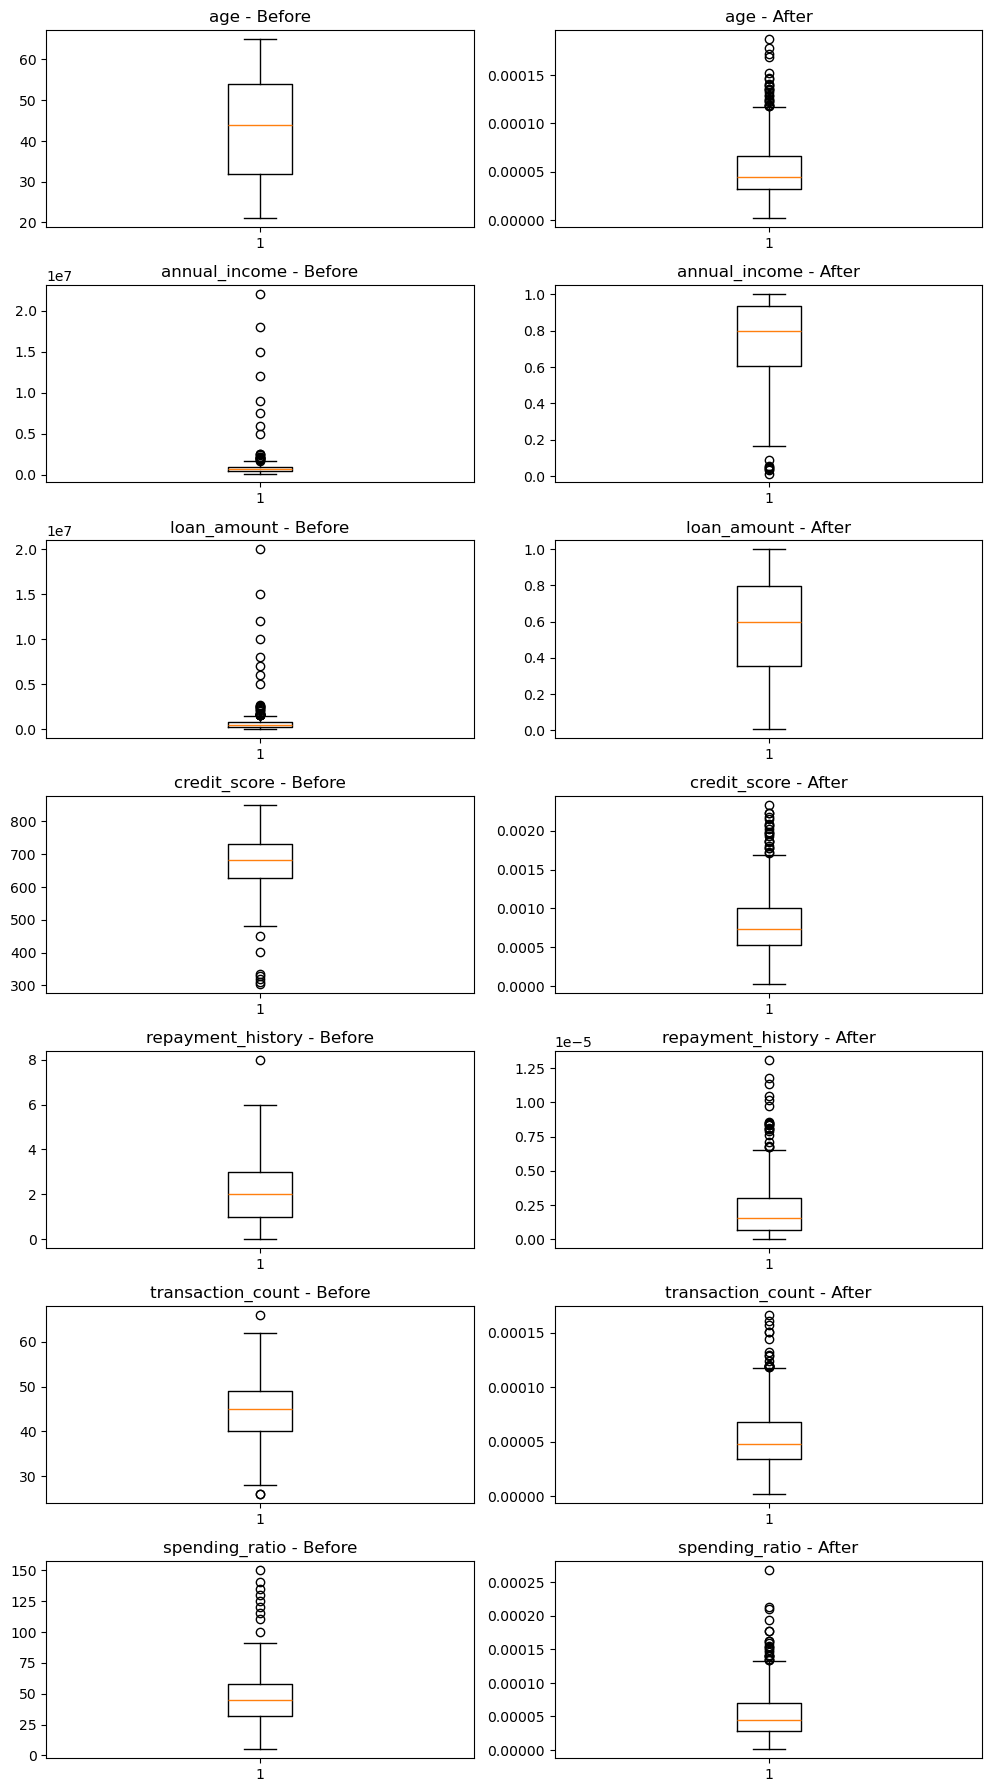

In [231]:

fig, axes = plt.subplots(
    7, 2,
    figsize=(10, 18)
)

for i, column in enumerate(numeric_columns):

    # Before
    axes[i, 0].boxplot(
        df[column].dropna()
    )
    axes[i, 0].set_title(column + " - Before")

    # After
    axes[i, 1].boxplot(
        df_normalized[column]
    )
    axes[i, 1].set_title(column + " - After")

plt.tight_layout(pad=1)
plt.show()

#### Interpretation
Normalization was applied to the numerical features using the Normalizer technique. The numerical values were scaled to a common magnitude on a row-wise basis. This reduces the effect of differences in the magnitude of numerical features.

## Step 11.3: Min-Max Scaling

In [232]:
from sklearn.preprocessing import MinMaxScaler

#### Numerical Column

In [233]:
numeric_columns = [
    "age",
    "annual_income",
    "loan_amount",
    "credit_score",
    "repayment_history",
    "transaction_count",
    "spending_ratio"
]

#### Handle Missing Vaules

In [236]:
df_minmax = df.copy()

df_minmax[numeric_columns] = df_minmax[numeric_columns].fillna(
    df_minmax[numeric_columns].median()
)

#### Apply Min-Msx calling

In [237]:
minmax_scaler = MinMaxScaler()

df_minmax[numeric_columns] = minmax_scaler.fit_transform(
    df_minmax[numeric_columns]
)

#### Before and after

In [238]:
print("Before Min-Max Scaling:")
display(df[numeric_columns].head())

print("\nAfter Min-Max Scaling:")
display(df_minmax[numeric_columns].head())

Before Min-Max Scaling:


,age,annual_income,loan_amount,credit_score,repayment_history,transaction_count,spending_ratio
0,59.0,1.194882e+06,1.172527e+06,600.610574,3,43,57.209164
1,49.0,9.248440e+05,1.985675e+05,611.120863,0,46,38.323377
2,35.0,2.110612e+06,7.154323e+04,701.966943,1,41,12.860149
3,63.0,4.301529e+05,3.123945e+05,675.789115,3,47,45.244326
4,28.0,1.026451e+06,1.001383e+06,320.000000,3,48,68.692816



After Min-Max Scaling:


,age,annual_income,loan_amount,credit_score,repayment_history,transaction_count,spending_ratio
0,0.863636,0.047821,0.055836,0.542405,0.375,0.425,0.360063
1,0.636364,0.035462,0.006994,0.561690,0.000,0.500,0.229816
2,0.318182,0.089731,0.000624,0.728380,0.125,0.375,0.054208
3,0.954545,0.012822,0.012702,0.680347,0.375,0.525,0.277547
4,0.159091,0.040112,0.047254,0.027523,0.375,0.550,0.439261


#### NOTE
##### 0 → minimum value
##### 1 → maximum value

#### Interpretation

Min-Max Scaling was applied to the numerical features. The values were transformed to a common range between 0 and 1. This makes features with different numerical ranges comparable without removing observations.

## Step 11.4: MaxAbs Scaling
MaxAbs Scaling divides each value by the maximum absolute value of its feature like(-1 se +1)

In [240]:
from sklearn.preprocessing import MaxAbsScaler

In [241]:
df_maxabs = df.copy()

numeric_columns = [
    "age",
    "annual_income",
    "loan_amount",
    "credit_score",
    "repayment_history",
    "transaction_count",
    "spending_ratio"
]

# Missing values ko median se fill
df_maxabs[numeric_columns] = df_maxabs[numeric_columns].fillna(
    df_maxabs[numeric_columns].median()
)

#### Apply MaxAbs Scaling

In [242]:
maxabs_scaler = MaxAbsScaler()

df_maxabs[numeric_columns] = maxabs_scaler.fit_transform(
    df_maxabs[numeric_columns]
)

In [243]:
print("Before MaxAbs Scaling:")
display(df[numeric_columns].head())

print("\nAfter MaxAbs Scaling:")
display(df_maxabs[numeric_columns].head())

Before MaxAbs Scaling:


,age,annual_income,loan_amount,credit_score,repayment_history,transaction_count,spending_ratio
0,59.0,1.194882e+06,1.172527e+06,600.610574,3,43,57.209164
1,49.0,9.248440e+05,1.985675e+05,611.120863,0,46,38.323377
2,35.0,2.110612e+06,7.154323e+04,701.966943,1,41,12.860149
3,63.0,4.301529e+05,3.123945e+05,675.789115,3,47,45.244326
4,28.0,1.026451e+06,1.001383e+06,320.000000,3,48,68.692816



After MaxAbs Scaling:


,age,annual_income,loan_amount,credit_score,repayment_history,transaction_count,spending_ratio
0,0.907692,0.054313,0.058626,0.706601,0.375,0.651515,0.381394
1,0.753846,0.042038,0.009928,0.718966,0.000,0.696970,0.255489
2,0.538462,0.095937,0.003577,0.825843,0.125,0.621212,0.085734
3,0.969231,0.019552,0.015620,0.795046,0.375,0.712121,0.301629
4,0.430769,0.046657,0.050069,0.376471,0.375,0.727273,0.457952


#### Interpretation

MaxAbs Scaling was applied to the numerical features by scaling each feature according to its maximum absolute value. This brings the features to a comparable scale while preserving the sign of the original values.

## Step 11.5: Robust Scaling
Robust Scaling scales data using the median and IQR instead of mean and standard deviation

In [245]:
from sklearn.preprocessing import RobustScaler

In [246]:
df_robust = df.copy()

numeric_columns = [
    "age",
    "annual_income",
    "loan_amount",
    "credit_score",
    "repayment_history",
    "transaction_count",
    "spending_ratio"
]

# Missing values ko median se fill
df_robust[numeric_columns] = df_robust[numeric_columns].fillna(
    df_robust[numeric_columns].median()
)

#### Apply Robust Scalling

In [247]:
robust_scaler = RobustScaler()

df_robust[numeric_columns] = robust_scaler.fit_transform(
    df_robust[numeric_columns]
)

#### Before snd After

In [248]:
print("Before Robust Scaling:")
display(df[numeric_columns].head())

print("\nAfter Robust Scaling:")
display(df_robust[numeric_columns].head())

Before Robust Scaling:


,age,annual_income,loan_amount,credit_score,repayment_history,transaction_count,spending_ratio
0,59.0,1.194882e+06,1.172527e+06,600.610574,3,43,57.209164
1,49.0,9.248440e+05,1.985675e+05,611.120863,0,46,38.323377
2,35.0,2.110612e+06,7.154323e+04,701.966943,1,41,12.860149
3,63.0,4.301529e+05,3.123945e+05,675.789115,3,47,45.244326
4,28.0,1.026451e+06,1.001383e+06,320.000000,3,48,68.692816



After Robust Scaling:


,age,annual_income,loan_amount,credit_score,repayment_history,transaction_count,spending_ratio
0,0.75,1.129647,1.502077,-0.858574,0.5,-0.222222,0.488689
1,0.25,0.568296,-0.536805,-0.747731,-1.0,0.111111,-0.245286
2,-0.45,3.033250,-0.802717,0.210340,-0.5,-0.444444,-1.234885
3,0.95,-0.460060,-0.298520,-0.065734,0.5,0.222222,0.023689
4,-0.80,0.779515,1.143805,-3.817920,0.5,0.333333,0.934988


#### Interpretation

Robust Scaling was applied to the numerical features using the median and interquartile range (IQR). This reduced the influence of extreme values while bringing the features to a comparable scale. No observations were removed.

# PART G — Feature Construction & Transformation

## Step 12.1 — FunctionTransformer

In [252]:
df = pd.read_csv("customer_credit_risk_dataset.csv")

### 1. Log Transformation

In [254]:
from sklearn.preprocessing import FunctionTransformer

log_transformer = FunctionTransformer(
    np.log1p
)

df["spending_ratio_log"] = log_transformer.transform(
    df[["spending_ratio"]]
)

In [255]:
display(
    df[
        ["spending_ratio", "spending_ratio_log"]
    ].head(10)
)

,spending_ratio,spending_ratio_log
0,57.209164,4.064043
1,38.323377,3.671819
2,12.860149,2.629018
3,45.244326,3.833939
4,68.692816,4.244097
5,60.896062,4.125457
6,43.627133,3.798342
7,65.263871,4.193645
8,48.460008,3.901164
9,62.661399,4.153578


### 2. Reciprocal Transformation

In [256]:
reciprocal_transformer = FunctionTransformer(
    lambda x: 1 / (x + 1)
)

df["spending_ratio_reciprocal"] = reciprocal_transformer.transform(
    df[["spending_ratio"]]
)

In [257]:
display(
    df[
        ["spending_ratio", "spending_ratio_reciprocal"]
    ].head(10)
)

,spending_ratio,spending_ratio_reciprocal
0,57.209164,0.017179
1,38.323377,0.025430
2,12.860149,0.072149
3,45.244326,0.021624
4,68.692816,0.014349
5,60.896062,0.016156
6,43.627133,0.022408
7,65.263871,0.015091
8,48.460008,0.020218
9,62.661399,0.015708


### Square Root transformation

In [258]:
sqrt_transformer = FunctionTransformer(
    np.sqrt
)

df["spending_ratio_sqrt"] = sqrt_transformer.transform(
    df[["spending_ratio"]]
)

In [259]:
display(
    df[
        ["spending_ratio", "spending_ratio_sqrt"]
    ].head(10)
)

,spending_ratio,spending_ratio_sqrt
0,57.209164,7.563674
1,38.323377,6.190588
2,12.860149,3.586105
3,45.244326,6.726390
4,68.692816,8.288113
5,60.896062,7.803593
6,43.627133,6.605084
7,65.263871,8.078606
8,48.460008,6.961322
9,62.661399,7.915895


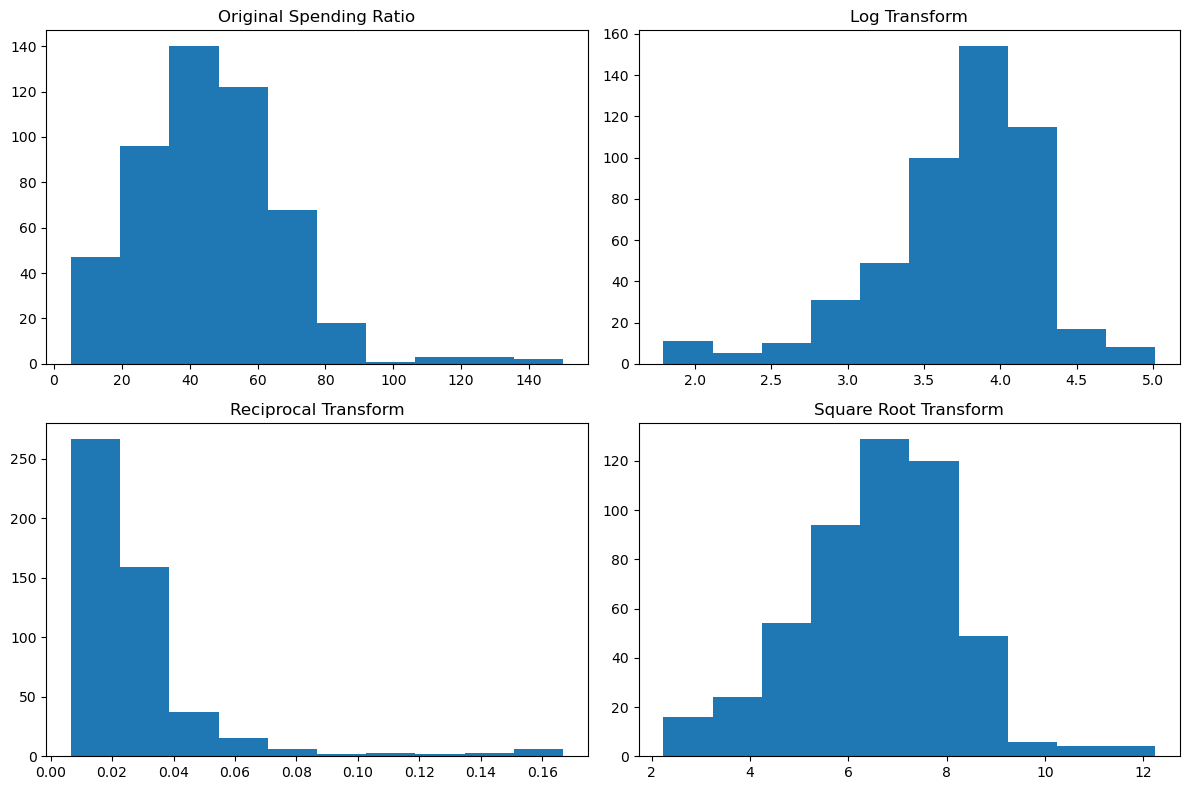

In [260]:


plt.figure(figsize=(12, 8))

# Original
plt.subplot(2, 2, 1)
plt.hist(df["spending_ratio"].dropna())
plt.title("Original Spending Ratio")

# Log
plt.subplot(2, 2, 2)
plt.hist(df["spending_ratio_log"].dropna())
plt.title("Log Transform")

# Reciprocal
plt.subplot(2, 2, 3)
plt.hist(df["spending_ratio_reciprocal"].dropna())
plt.title("Reciprocal Transform")

# Square Root
plt.subplot(2, 2, 4)
plt.hist(df["spending_ratio_sqrt"].dropna())
plt.title("Square Root Transform")

plt.tight_layout()
plt.show()

#### Interpretation 
FunctionTransformer was used to apply log, reciprocal and square-root transformations to the spending_ratio feature. These transformations change the distribution and can help reduce the effect of skewness in numerical data.

## Step 12.2: PowerTransformer

In [263]:
from sklearn.preprocessing import PowerTransformer

In [264]:
df = pd.read_csv("customer_credit_risk_dataset.csv")

### Box-Cox Transformation 
annual_income positive numerical feature hai, isliye Box-Cox ke liye suitable hai

##### Fill Missing Value Throw Median (if any)

In [268]:
df_power = df.copy()

df_power["annual_income"] = df_power["annual_income"].fillna(
    df_power["annual_income"].median()
)

#### apply Box-cox

In [269]:
boxcox_transformer = PowerTransformer(
    method="box-cox"
)

df_power["annual_income_boxcox"] = boxcox_transformer.fit_transform(
    df_power[["annual_income"]]
)

In [270]:
display(
    df_power[
        ["annual_income", "annual_income_boxcox"]
    ].head(10)
)

,annual_income,annual_income_boxcox
0,1.194882e+06,1.013965
1,9.248440e+05,0.642579
2,2.110612e+06,1.724548
3,4.301529e+05,-0.698287
4,1.026451e+06,0.797893
5,3.714611e+05,-1.000807
6,2.673399e+05,-1.740935
7,2.121790e+05,-2.316660
8,8.739740e+05,0.555779
9,7.193217e+05,0.242919


### 4. Yeo-Johnson Transformation

In [271]:
df_power["spending_ratio"] = df_power["spending_ratio"].fillna(
    df_power["spending_ratio"].median()
)

#### Apply Yeo-johnson

In [272]:
yeojohnson_transformer = PowerTransformer(
    method="yeo-johnson"
)

df_power["spending_ratio_yeojohnson"] = yeojohnson_transformer.fit_transform(
    df_power[["spending_ratio"]]
)

In [273]:
display(
    df_power[
        ["spending_ratio", "spending_ratio_yeojohnson"]
    ].head(10)
)

,spending_ratio,spending_ratio_yeojohnson
0,57.209164,0.598303
1,38.323377,-0.273837
2,12.860149,-1.814871
3,45.244326,0.062445
4,68.692816,1.071215
5,60.896062,0.754011
6,43.627133,-0.014164
7,65.263871,0.933614
8,48.460008,0.211572
9,62.661399,0.827210


#### Before And After graph

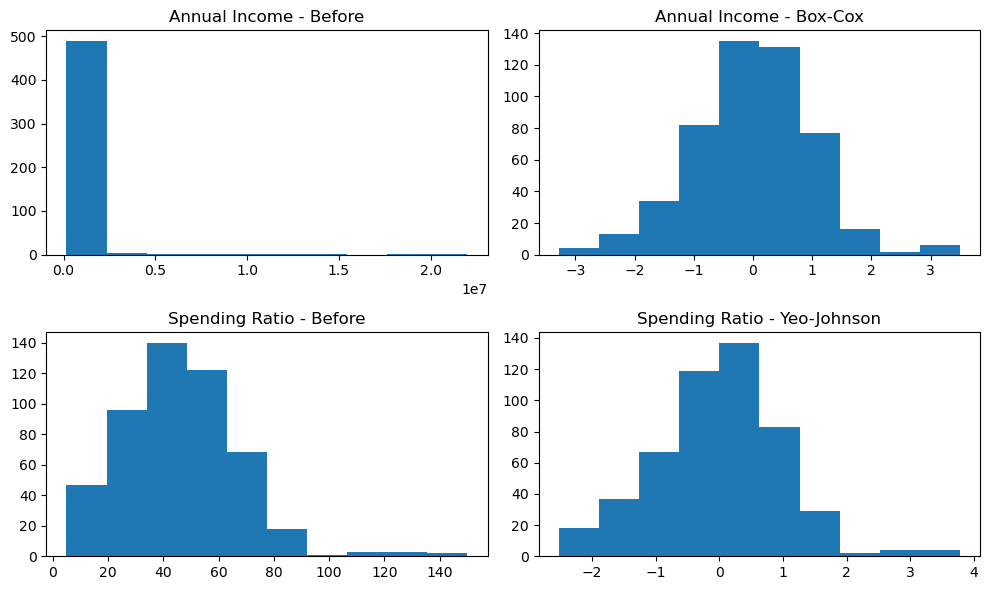

In [274]:
plt.figure(figsize=(10, 6))

# Box-Cox
plt.subplot(2, 2, 1)
plt.hist(df_power["annual_income"].dropna())
plt.title("Annual Income - Before")

plt.subplot(2, 2, 2)
plt.hist(df_power["annual_income_boxcox"].dropna())
plt.title("Annual Income - Box-Cox")

# Yeo-Johnson
plt.subplot(2, 2, 3)
plt.hist(df_power["spending_ratio"].dropna())
plt.title("Spending Ratio - Before")

plt.subplot(2, 2, 4)
plt.hist(df_power["spending_ratio_yeojohnson"].dropna())
plt.title("Spending Ratio - Yeo-Johnson")

plt.tight_layout()
plt.show()

#### Interpretation

PowerTransformer was used to transform numerical features using Box-Cox and Yeo-Johnson methods. Box-Cox transformation was applied to annual_income, while Yeo-Johnson transformation was applied to spending_ratio. These transformations help make skewed numerical distributions more suitable for analysis and machine learning.

## Step 12.3: ColumnTransformer
ColumnTransformer → apply different preprocessing steps to different columns.

In [275]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

#### Select Both Column

In [276]:
numeric_columns = [
    "age",
    "annual_income",
    "loan_amount",
    "credit_score",
    "repayment_history",
    "transaction_count",
    "spending_ratio"
]

categorical_columns = [
    "gender",
    "region",
    "education_level",
    "employment_type",
    "loan_purpose"
]

In [279]:
df_ct = df.copy()

# Numerical missing values
df_ct[numeric_columns] = df_ct[numeric_columns].fillna(
    df_ct[numeric_columns].median()
)

# Categorical missing values
df_ct[categorical_columns] = df_ct[categorical_columns].fillna(
    df_ct[categorical_columns].mode().iloc[0]
)

#### Create The Column Transform

In [280]:
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_columns),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ]
)

#### transformation apply

In [281]:
transformed_data = preprocessor.fit_transform(df_ct)

In [282]:
print("Original shape:", df_ct.shape)
print("Transformed shape:", transformed_data.shape)

Original shape: (500, 15)
Transformed shape: (500, 26)


In [288]:
print(transformed_data)

[[ 1.23637926  0.17970519  0.30590775 ...  0.          0.
   0.        ]
 [ 0.44097315  0.01235599 -0.37281823 ...  0.          1.
   0.        ]
 [-0.67259541  0.74720444 -0.46133797 ...  0.          1.
   0.        ]
 ...
 [ 0.60005437 -0.41522377 -0.31557687 ...  0.          0.
   0.        ]
 [-1.70662335  0.0579447   0.20387276 ...  0.          1.
   0.        ]
 [ 0.91821681 -0.39597211 -0.24095996 ...  0.          0.
   0.        ]]


#### 

## 13 — Construct New Features

#### Step 13.1: Debt-to-Income Ratio

In [286]:
df = pd.read_csv("customer_credit_risk_dataset.csv")

### Create dept to income ratio

In [289]:
df["debt_to_income_ratio"] = (
    df["loan_amount"] / df["annual_income"]
)

In [290]:
display(
    df[
        [
            "annual_income",
            "loan_amount",
            "debt_to_income_ratio"
        ]
    ].head(10)
)

,annual_income,loan_amount,debt_to_income_ratio
0,1.194882e+06,1.172527e+06,0.981291
1,9.248440e+05,1.985675e+05,0.214704
2,2.110612e+06,7.154323e+04,0.033897
3,4.301529e+05,3.123945e+05,0.726241
4,1.026451e+06,1.001383e+06,0.975578
5,3.714611e+05,1.338161e+05,0.360243
6,2.673399e+05,1.969695e+05,0.736776
7,2.121790e+05,1.500000e+07,70.695016
8,8.739740e+05,2.719443e+06,3.111584
9,7.193217e+05,1.739033e+05,0.241760


#### Graph 

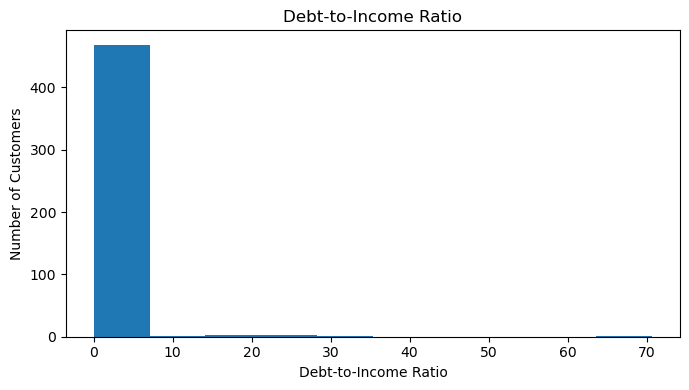

In [292]:
plt.figure(figsize=(7, 4))

plt.hist(df["debt_to_income_ratio"].dropna())

plt.title("Debt-to-Income Ratio")
plt.xlabel("Debt-to-Income Ratio")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

#### Interpretation

The Debt-to-Income ratio was constructed by dividing the loan amount by annual income. This new feature represents the loan amount relative to the customer's annual income and can help indicate the customer's financial burden.
###### ForExaample 
###### Annual Income = ₹5,00,000
###### Loan Amount = ₹1,00,000

##### DTI = 1,00,000 / 5,00,000
##### = 0.20

### Step 13.2: Average Monthly Transactions

#### Create Feature

In [293]:
df["average_monthly_transactions"] = (
    df["transaction_count"] / 6
)

In [294]:
display(
    df[
        [
            "transaction_count",
            "average_monthly_transactions"
        ]
    ].head(10)
)

,transaction_count,average_monthly_transactions
0,43,7.166667
1,46,7.666667
2,41,6.833333
3,47,7.833333
4,48,8.000000
5,62,10.333333
6,35,5.833333
7,45,7.500000
8,43,7.166667
9,57,9.500000


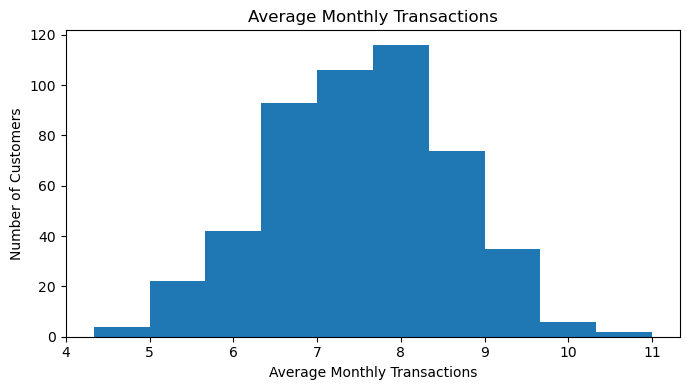

In [301]:
\
plt.figure(figsize=(7, 4))

plt.hist(
    df["average_monthly_transactions"].dropna()
)

plt.title("Average Monthly Transactions")
plt.xlabel("Average Monthly Transactions")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

## Interpretation

The Average Monthly Transactions feature was constructed by dividing the total transaction count for the last 6 months by 6. This feature represents the customer's average number of transactions per month.

### Step 13.3: Spending-to-Income Ratio

#### Creat Feature

In [303]:
df["spending_to_income_ratio"] = (
    df["spending_ratio"] / df["annual_income"]
)

In [304]:
display(
    df[
        [
            "spending_ratio",
            "annual_income",
            "spending_to_income_ratio"
        ]
    ].head(10)
)

,spending_ratio,annual_income,spending_to_income_ratio
0,57.209164,1.194882e+06,0.000048
1,38.323377,9.248440e+05,0.000041
2,12.860149,2.110612e+06,0.000006
3,45.244326,4.301529e+05,0.000105
4,68.692816,1.026451e+06,0.000067
5,60.896062,3.714611e+05,0.000164
6,43.627133,2.673399e+05,0.000163
7,65.263871,2.121790e+05,0.000308
8,48.460008,8.739740e+05,0.000055
9,62.661399,7.193217e+05,0.000087


### Graph

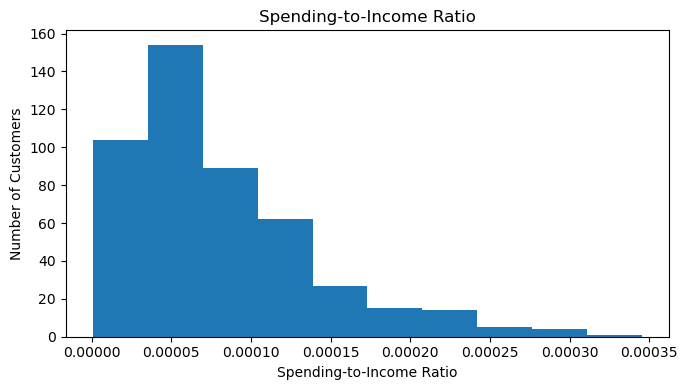

In [306]:
plt.figure(figsize=(7, 4))

plt.hist(
    df["spending_to_income_ratio"].dropna()
)

plt.title("Spending-to-Income Ratio")
plt.xlabel("Spending-to-Income Ratio")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

#### Interpretation

The Spending-to-Income ratio was constructed using the spending ratio and annual income. This new feature represents the customer's spending level relative to their annual income and can be used to understand the relationship between spending and income.

## PART H — FINAL DELIVERABLE

### 14 Final Cleaned and Transformed Dataset
#### Final dataset ko CSV file mein save kiya

In [311]:
df_final.to_csv(
    "final_cleaned_transformed_dataset.csv",
    index=False
)

# Final dataset display karna
print("Final Cleaned and Transformed Dataset")
print("Shape:", df_final.shape)

display(df_final.head(10))

Final Cleaned and Transformed Dataset
Shape: (500, 27)


,age,annual_income,loan_amount,credit_score,repayment_history,transaction_count,spending_ratio,default_flag,join_year,join_month,...,loan_purpose_Business,loan_purpose_Car,loan_purpose_Education,loan_purpose_Home,loan_purpose_Other,income_group,high_credit_score,income_quantile,debt_to_income_ratio,average_monthly_transactions
0,1.236379,0.413617,0.568766,-1.007421,0.816621,-0.281944,0.555857,0,2025,6,...,0.0,1.0,0.0,0.0,0.0,Very High,0,High,0.981291,7.166667
1,0.440973,0.108901,-0.542191,-0.870006,-1.252520,0.176750,-0.364728,0,2022,12,...,0.0,0.0,0.0,1.0,0.0,High,0,Medium-High,0.214704,7.666667
2,-0.672595,1.446943,-0.661371,0.317738,-0.562806,-0.587740,-1.605931,0,2020,7,...,0.0,0.0,0.0,1.0,0.0,Very High,1,High,0.044577,6.833333
3,1.554542,-0.449317,-0.412353,-0.024518,0.816621,0.329648,-0.027368,0,2025,7,...,1.0,0.0,0.0,0.0,0.0,Medium,0,Low,0.726241,7.833333
4,-1.229380,0.223557,0.373549,-3.614932,0.816621,0.482546,1.115626,0,2019,8,...,0.0,0.0,0.0,1.0,0.0,Very High,0,High,0.975578,8.000000
5,-0.195352,-0.515546,-0.616050,0.806039,0.126907,2.317321,0.735574,0,2019,4,...,1.0,0.0,0.0,0.0,0.0,Medium,1,Low,0.360243,10.000000
6,1.236379,-0.633039,-0.544014,0.803994,-0.562806,-1.505127,-0.106197,0,2021,5,...,0.0,0.0,0.0,1.0,0.0,Low,1,Low,0.736776,5.833333
7,-0.354433,-0.695283,7.227337,0.288505,1.506334,0.023852,0.948483,0,2022,11,...,1.0,0.0,0.0,0.0,0.0,Low,0,Low,33.038138,7.500000
8,-0.036271,0.051499,2.333271,-0.912966,2.885762,-0.281944,0.129380,1,2023,12,...,1.0,0.0,0.0,0.0,0.0,High,0,Medium-High,3.111584,7.166667
9,-0.990758,-0.123014,-0.570324,0.349554,0.126907,1.858627,0.821626,0,2018,7,...,0.0,0.0,0.0,1.0,0.0,High,1,Medium-High,0.241760,9.500000


In [312]:
print("Total Missing Values:", df_final.isnull().sum().sum())
print("Total Duplicate Rows:", df_final.duplicated().sum())
print("Final Shape:", df_final.shape)

Total Missing Values: 0
Total Duplicate Rows: 0
Final Shape: (500, 27)


## 15 Final Data Preprocessing & Feature Engineering Report

## 1. Missing Value Strategies Used and Their Effectiveness

Different missing value techniques were explored, including Simple Imputer,
Most Frequent Category Imputation, Missing Indicator with Random Sample
Imputation, KNN Imputer, MICE Algorithm and Complete Case Analysis.

For the final dataset, numerical missing values were handled using median
imputation and categorical missing values were handled using the most
frequent category. After preprocessing, the final dataset contains no
missing values.

## 2. Outlier Handling Results

Outliers were detected and treated using Z-score, IQR, Percentile and
Winsorization methods.

For the final dataset, Winsorization was used to cap extreme numerical
values at the selected percentile limits without removing customer records.
This helped reduce the effect of extreme values while preserving the
dataset size.

## 3. Encoding Methods Applied

Ordinal Encoding was applied to the education_level variable because
education levels have a natural order.

One-Hot Encoding was applied to region and loan_purpose to convert
categorical values into numerical binary columns.

Binary representation was used for the binary feature.

## 4. Scaling and Transformations Applied and Why

Different scaling techniques were studied, including Standardization
(Z-score), Normalization, Min-Max Scaling, MaxAbs Scaling and Robust Scaling.

The required transformations included Log, Reciprocal, Square Root,
Box-Cox and Yeo-Johnson transformations.

Scaling was used to bring numerical features to suitable/comparable scales,
while transformations were used to modify numerical distributions and
reduce the effect of skewness.

## 5. Newly Engineered Features and Their Usefulness

Three new features were constructed:

1. Debt-to-Income Ratio
   = loan_amount / annual_income

2. Average Monthly Transactions
   = transaction_count / 6

3. Spending-to-Income Ratio
   = spending_ratio

These features provide additional information about financial burden,
transaction behaviour and spending behaviour of customers.

## 6. Final Dataset Shape and Readiness for ML Modeling

The final cleaned and transformed dataset contains:

Rows: 500
Columns: 34
Missing Values: 0
Duplicate Rows: 0

The final dataset contains cleaned, encoded, transformed, scaled and
engineered features along with the target variable default_flag.

Therefore, the final dataset is prepared for further machine learning
modeling.